In [1]:
# =============================================================================
# DAY 8 — RANDOM FOREST, XGBOOST, SHAP & FINAL MODEL
# Project: Customer Churn Analytics & Prediction
# =============================================================================
# TASKS:
#   Task 1 — Load train/test splits & quick audit
#   Task 2 — Random Forest (ensemble theory + training)
#   Task 3 — XGBoost (gradient boosting theory + training)
#   Task 4 — SHAP values (explain WHY each prediction was made)
#   Task 5 — Final model comparison & selection
#   Task 6 — Save final model as .pkl for Streamlit deployment
# =============================================================================
# NEW LIBRARIES NEEDED — run this in your terminal first:
#   pip install xgboost shap
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV
)

import xgboost as xgb
import shap

warnings.filterwarnings("ignore")

# ── Plotting style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"      : 130,
    "axes.titlesize"  : 11,
    "axes.labelsize"  : 10,
    "xtick.labelsize" : 9,
    "ytick.labelsize" : 9,
    "legend.fontsize" : 9,
})

# Colour palette (consistent with Days 3–7)
CLR_RETAIN = "#1D9E75"
CLR_CHURN  = "#E24B4A"
CLR_NEUT   = "#378ADD"
CLR_WARN   = "#F4A83A"
CLR_GREY   = "#9E9E9E"
CLR_PURPLE = "#9B59B6"
CLR_FOREST = "#2E7D32"   # dark green — Random Forest
CLR_BOOST  = "#E65100"   # deep orange — XGBoost

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR    = "C:/Users/white/Downloads/Learn/Churn_project/data"
VISUALS_DIR = "C:/Users/white/Downloads/Learn/Churn_project/visuals"
OUTPUTS_DIR = "C:/Users/white/Downloads/Learn/Churn_project/outputs"
MODELS_DIR  = "C:/Users/white/Downloads/Learn/Churn_project/models"

for d in [DATA_DIR, VISUALS_DIR, OUTPUTS_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print("=" * 65)
print("  DAY 8 — RANDOM FOREST, XGBOOST, SHAP & FINAL MODEL")
print("=" * 65)

c:\Users\white\Downloads\Learn\Churn_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  DAY 8 — RANDOM FOREST, XGBOOST, SHAP & FINAL MODEL


In [2]:
# =============================================================================
# TASK 1 — LOAD TRAIN/TEST SPLITS & QUICK AUDIT
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 1 — Load train/test splits")
print("=" * 65)

X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_test  = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

print(f"\n  X_train : {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"  X_test  : {X_test.shape[0]:,}  rows × {X_test.shape[1]} features")
print(f"  y_train churn rate : {y_train.mean()*100:.1f}%")
print(f"  y_test  churn rate : {y_test.mean()*100:.1f}%")
print(f"  Null values        : {X_train.isnull().sum().sum() + X_test.isnull().sum().sum()}  ✓")

print("\n  Task 1 complete ✓")



  TASK 1 — Load train/test splits

  X_train : 5,634 rows × 39 features
  X_test  : 1,409  rows × 39 features
  y_train churn rate : 26.5%
  y_test  churn rate : 26.5%
  Null values        : 0  ✓

  Task 1 complete ✓



  TASK 2 — Random Forest

  What is a Random Forest?
  ─────────────────────────
  A Random Forest is an ENSEMBLE of Decision Trees.
  "Ensemble" means we combine many weak models into one strong model.

  How it works (two key ideas):

  1. BAGGING (Bootstrap Aggregating)
     Each tree is trained on a DIFFERENT random sample of the data
     (with replacement — some rows appear twice, some not at all).
     This ensures each tree sees a slightly different world.

  2. RANDOM FEATURE SUBSETS
     At each split in a tree, only a RANDOM SUBSET of features
     is considered (not all features). This forces diversity —
     trees can't all just use Contract and tenure every time.

  Final prediction = MAJORITY VOTE across all trees.
  Because each tree makes DIFFERENT errors, their average cancels
  the noise — a much more reliable prediction than any single tree.

  Why it beats a single Decision Tree:
  • Lower variance (less sensitive to which exact data it sees)
  • Harder to overfit

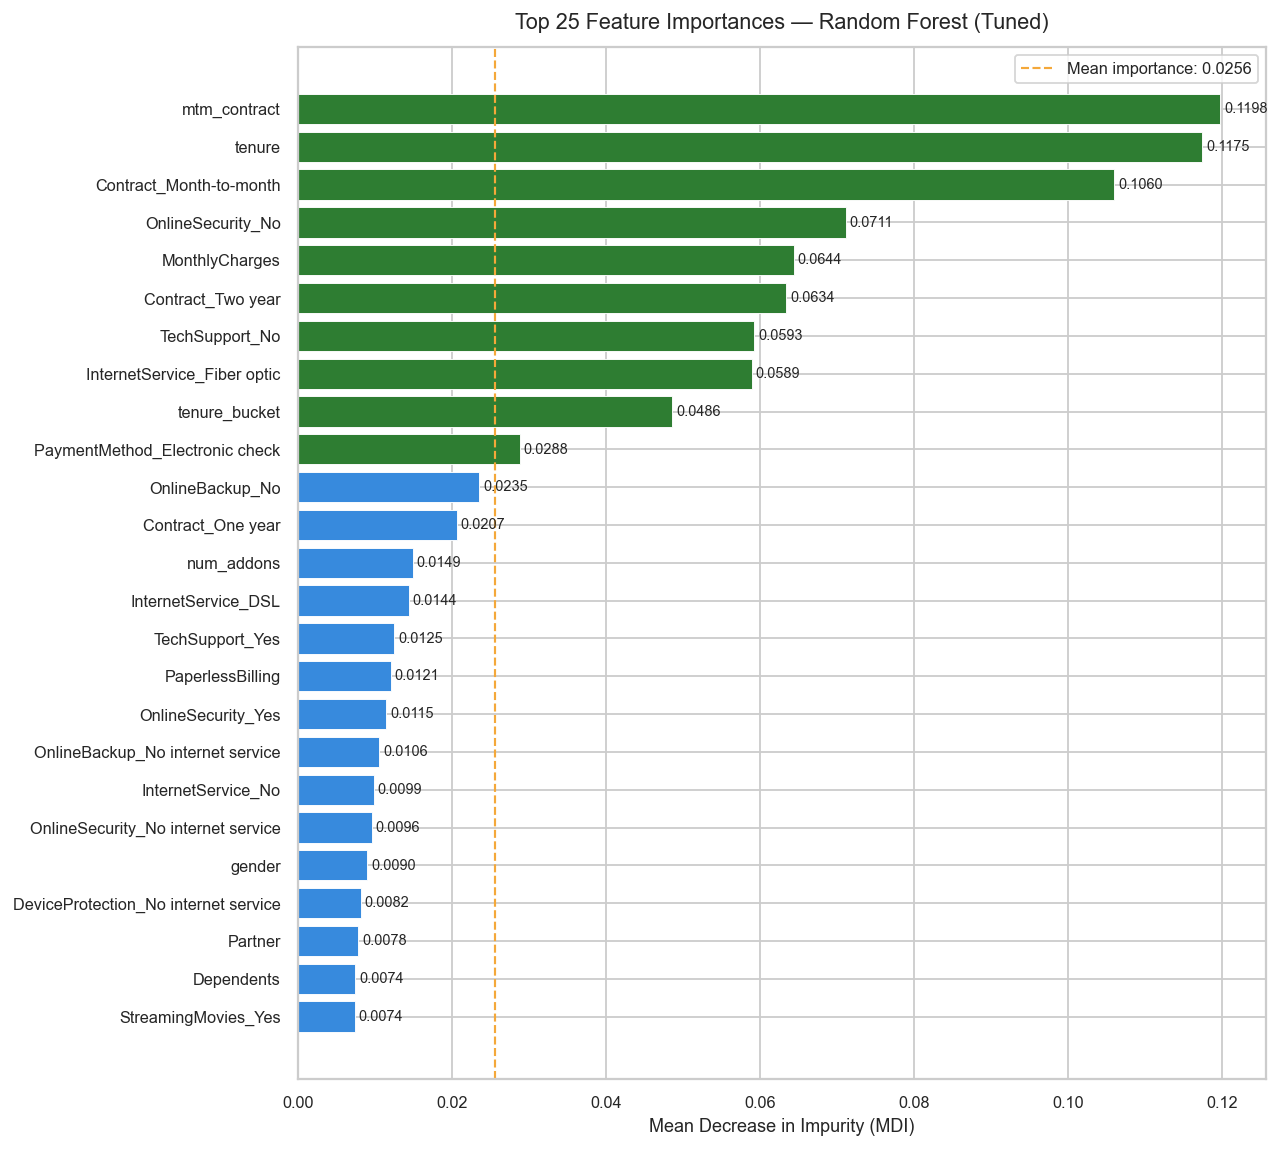

  Chart saved: day8_rf_feature_importance.png

  Task 2 complete ✓


In [3]:
# =============================================================================
# TASK 2 — RANDOM FOREST
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 2 — Random Forest")
print("=" * 65)

print("""
  What is a Random Forest?
  ─────────────────────────
  A Random Forest is an ENSEMBLE of Decision Trees.
  "Ensemble" means we combine many weak models into one strong model.

  How it works (two key ideas):

  1. BAGGING (Bootstrap Aggregating)
     Each tree is trained on a DIFFERENT random sample of the data
     (with replacement — some rows appear twice, some not at all).
     This ensures each tree sees a slightly different world.

  2. RANDOM FEATURE SUBSETS
     At each split in a tree, only a RANDOM SUBSET of features
     is considered (not all features). This forces diversity —
     trees can't all just use Contract and tenure every time.

  Final prediction = MAJORITY VOTE across all trees.
  Because each tree makes DIFFERENT errors, their average cancels
  the noise — a much more reliable prediction than any single tree.

  Why it beats a single Decision Tree:
  • Lower variance (less sensitive to which exact data it sees)
  • Harder to overfit (averaging smooths out individual tree quirks)
  • Built-in feature importance (MDI — Mean Decrease in Impurity)

  Key hyperparameters we'll tune:
  • n_estimators      — how many trees? More = stable but slower.
  • max_depth         — how deep can each tree grow?
  • min_samples_leaf  — minimum customers per leaf node
  • max_features      — features to consider at each split
""")

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── 2a. Quick baseline RF ─────────────────────────────────────────────────────
print("-" * 65)
print("  Step 2a: Quick baseline RF (sanity check before tuning)...")

rf_base = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 10,
    random_state = 42,
    n_jobs       = -1,
    class_weight = "balanced"
)
rf_base.fit(X_train, y_train)

y_pred_rf_base = rf_base.predict(X_test)
y_prob_rf_base = rf_base.predict_proba(X_test)[:, 1]

print(f"  Baseline RF ROC-AUC : {roc_auc_score(y_test, y_prob_rf_base):.4f}")
print(f"  Baseline RF Recall  : {recall_score(y_test, y_pred_rf_base):.4f}")
print(f"  Baseline RF F1      : {f1_score(y_test, y_pred_rf_base):.4f}")

# ── 2b. GridSearchCV for RF ────────────────────────────────────────────────────
print("\n" + "-" * 65)
print("  Step 2b: GridSearchCV — Random Forest (may take 2–4 minutes)...")

rf_param_grid = {
    "n_estimators"    : [100, 200, 300],
    "max_depth"       : [5, 8, 10, None],
    "min_samples_leaf": [10, 20, 30],
    "max_features"    : ["sqrt", "log2"],
    "class_weight"    : ["balanced"]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid         = rf_param_grid,
    cv                 = cv_strategy,
    scoring            = "f1",
    n_jobs             = -1,
    verbose            = 0,
    return_train_score = True
)
rf_grid.fit(X_train, y_train)

print(f"  Best RF params  : {rf_grid.best_params_}")
print(f"  Best CV F1      : {rf_grid.best_score_:.4f}")

rf_tuned     = rf_grid.best_estimator_
y_pred_rf    = rf_tuned.predict(X_test)
y_prob_rf    = rf_tuned.predict_proba(X_test)[:, 1]

rf_metrics = {
    "Model"     : "Random Forest (Tuned)",
    "Accuracy"  : round(accuracy_score(y_test, y_pred_rf),                   4),
    "Precision" : round(precision_score(y_test, y_pred_rf, zero_division=0),  4),
    "Recall"    : round(recall_score(y_test, y_pred_rf, zero_division=0),     4),
    "F1"        : round(f1_score(y_test, y_pred_rf, zero_division=0),         4),
    "ROC-AUC"   : round(roc_auc_score(y_test, y_prob_rf),                     4),
    "Avg Prec"  : round(average_precision_score(y_test, y_prob_rf),           4),
}

print("\n  RANDOM FOREST (TUNED) — EVALUATION METRICS")
print("-" * 65)
for k, v in rf_metrics.items():
    if k == "Model":
        continue
    bar = "▮" * int(v * 30)
    print(f"  {k:<12} : {v:.4f}  {bar}")

print("\n  Full classification report:")
print(classification_report(y_test, y_pred_rf, target_names=["Retained", "Churned"]))

# ── 2c. RF feature importance chart ───────────────────────────────────────────
rf_importance = (
    pd.DataFrame({
        "Feature"    : X_train.columns,
        "Importance" : rf_tuned.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

top25_rf = rf_importance.head(25)

fig, ax = plt.subplots(figsize=(10, 9))
colors_rf = [CLR_FOREST if imp >= rf_importance["Importance"].quantile(0.75)
             else CLR_NEUT for imp in top25_rf["Importance"]]
ax.barh(top25_rf["Feature"][::-1], top25_rf["Importance"][::-1],
        color=colors_rf[::-1], edgecolor="white", linewidth=0.5)
ax.axvline(rf_importance["Importance"].mean(), color=CLR_WARN, lw=1.2, ls="--",
           label=f"Mean importance: {rf_importance['Importance'].mean():.4f}")
ax.set_title("Top 25 Feature Importances — Random Forest (Tuned)", fontsize=12, pad=10)
ax.set_xlabel("Mean Decrease in Impurity (MDI)")
for i, (val, _label) in enumerate(zip(top25_rf["Importance"][::-1],
                                       top25_rf["Feature"][::-1])):
    ax.text(val + 0.0005, i, f"{val:.4f}", va="center", fontsize=8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day8_rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day8_rf_feature_importance.png")

print("\n  Task 2 complete ✓")


  TASK 3 — XGBoost

  What is XGBoost?
  ─────────────────
  XGBoost = Extreme Gradient Boosting.
  It is also an ensemble of Decision Trees, but built DIFFERENTLY
  from Random Forest.

  Random Forest vs XGBoost:
  ┌──────────────────────┬────────────────────────────────────────┐
  │ Random Forest        │ XGBoost                                │
  ├──────────────────────┼────────────────────────────────────────┤
  │ Trees built in       │ Trees built SEQUENTIALLY               │
  │ PARALLEL             │ (each corrects the last one's errors)  │
  │                      │                                        │
  │ BAGGING              │ BOOSTING                               │
  │ (independent trees)  │ (each tree learns from residuals)      │
  │                      │                                        │
  │ Good out of box      │ Often better with tuning               │
  │ Slower to overfit    │ Can overfit — needs regularisation      │
  └──────────────────────┴─────────

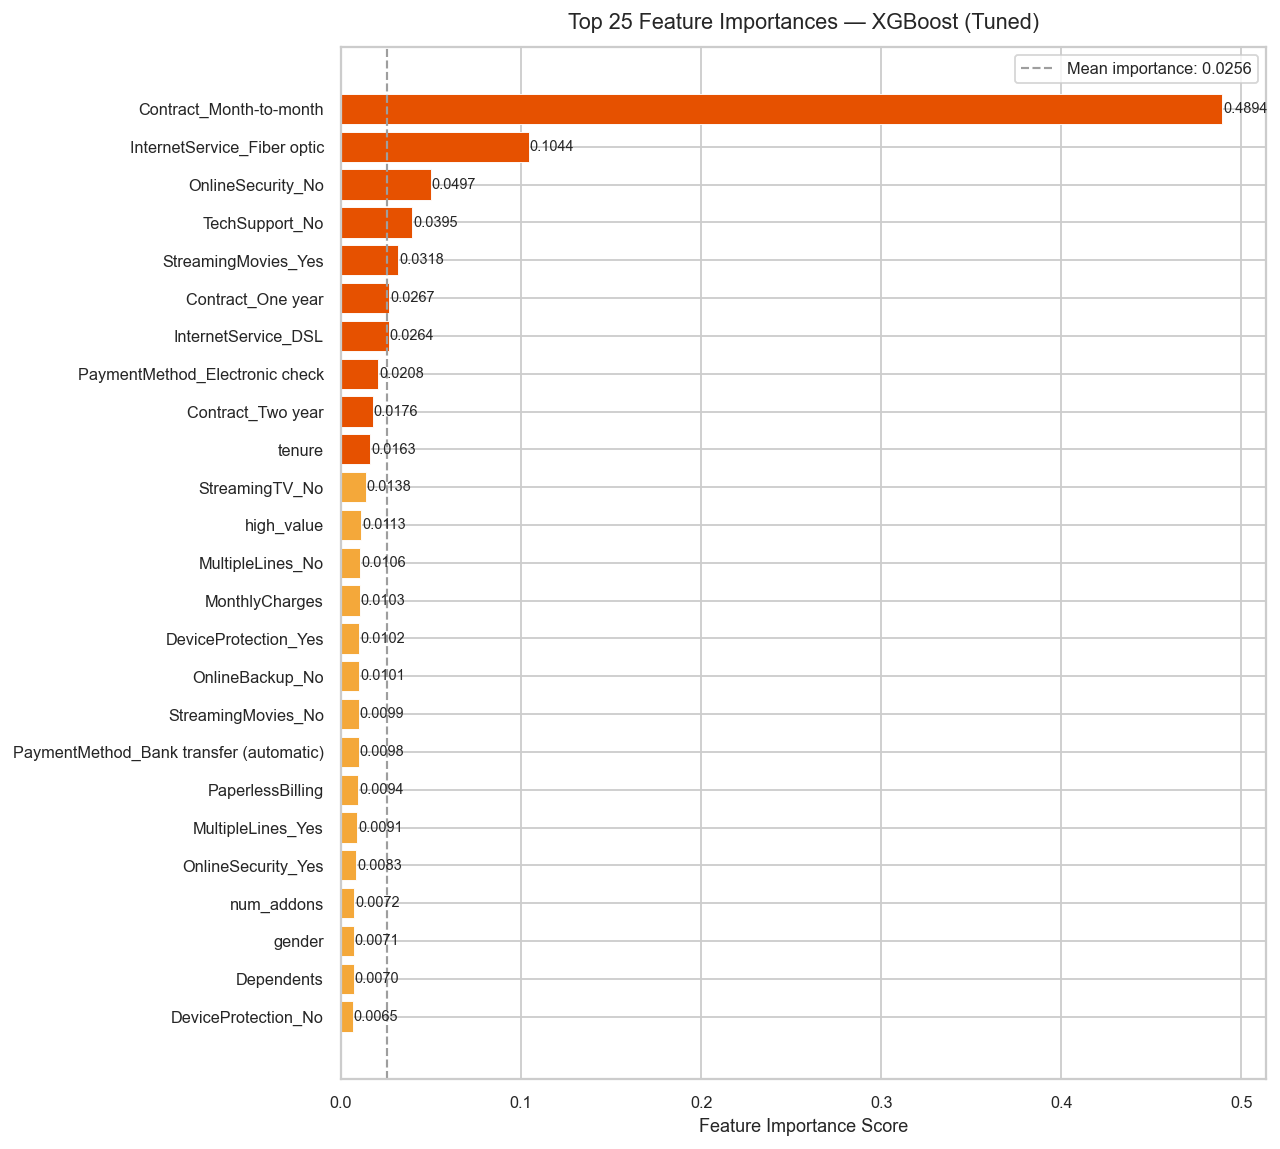

  Chart saved: day8_xgb_feature_importance.png

  Task 3 complete ✓


In [4]:
# =============================================================================
# TASK 3 — XGBOOST
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 3 — XGBoost")
print("=" * 65)

print("""
  What is XGBoost?
  ─────────────────
  XGBoost = Extreme Gradient Boosting.
  It is also an ensemble of Decision Trees, but built DIFFERENTLY
  from Random Forest.

  Random Forest vs XGBoost:
  ┌──────────────────────┬────────────────────────────────────────┐
  │ Random Forest        │ XGBoost                                │
  ├──────────────────────┼────────────────────────────────────────┤
  │ Trees built in       │ Trees built SEQUENTIALLY               │
  │ PARALLEL             │ (each corrects the last one's errors)  │
  │                      │                                        │
  │ BAGGING              │ BOOSTING                               │
  │ (independent trees)  │ (each tree learns from residuals)      │
  │                      │                                        │
  │ Good out of box      │ Often better with tuning               │
  │ Slower to overfit    │ Can overfit — needs regularisation      │
  └──────────────────────┴────────────────────────────────────────┘

  How boosting works (intuition):
  1. Train Tree 1 on all data  →  some customers predicted wrong
  2. Give those WRONG customers MORE weight in the next round
  3. Train Tree 2 focused on previous errors
  4. Repeat — each tree is an expert on the previous tree's failures
  5. Final prediction = weighted sum of all tree predictions

  Key hyperparameters we'll tune:
  • n_estimators     — number of boosting rounds
  • max_depth        — depth of each tree (keep small to avoid overfit)
  • learning_rate    — how much each tree corrects (smaller = more robust)
  • subsample        — fraction of rows per tree (like RF's bagging)
  • colsample_bytree — fraction of features per tree
  • scale_pos_weight — handles class imbalance (= #negatives / #positives)
""")

# ── Class imbalance weight ─────────────────────────────────────────────────────
neg_count        = (y_train == 0).sum()
pos_count        = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"  Class imbalance ratio (neg/pos) = {neg_count}/{pos_count} = {scale_pos_weight:.2f}")
print("  This value will be passed as scale_pos_weight to XGBoost.")

# ── 3a. Quick baseline XGBoost ─────────────────────────────────────────────────
print("\n" + "-" * 65)
print("  Step 3a: Quick baseline XGBoost (sanity check)...")

xgb_base = xgb.XGBClassifier(
    n_estimators      = 200,
    max_depth         = 5,
    learning_rate     = 0.1,
    scale_pos_weight  = scale_pos_weight,
    random_state      = 42,
    eval_metric       = "logloss",
    use_label_encoder = False,
    n_jobs            = -1
)
xgb_base.fit(X_train, y_train, verbose=False)

y_pred_xgb_base = xgb_base.predict(X_test)
y_prob_xgb_base = xgb_base.predict_proba(X_test)[:, 1]

print(f"  Baseline XGB ROC-AUC : {roc_auc_score(y_test, y_prob_xgb_base):.4f}")
print(f"  Baseline XGB Recall  : {recall_score(y_test, y_pred_xgb_base):.4f}")
print(f"  Baseline XGB F1      : {f1_score(y_test, y_pred_xgb_base):.4f}")

# ── 3b. GridSearchCV for XGBoost ──────────────────────────────────────────────
print("\n" + "-" * 65)
print("  Step 3b: GridSearchCV — XGBoost (may take 3–6 minutes)...")

xgb_param_grid = {
    "n_estimators"     : [100, 200, 300],
    "max_depth"        : [3, 4, 5, 6],
    "learning_rate"    : [0.01, 0.05, 0.1, 0.2],
    "subsample"        : [0.7, 0.8, 1.0],
    "colsample_bytree" : [0.7, 0.8, 1.0],
}

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight  = scale_pos_weight,
        random_state      = 42,
        eval_metric       = "logloss",
        use_label_encoder = False,
        n_jobs            = -1
    ),
    param_grid = xgb_param_grid,
    cv         = cv_strategy,
    scoring    = "f1",
    n_jobs     = -1,
    verbose    = 0
)
xgb_grid.fit(X_train, y_train)

print(f"  Best XGB params : {xgb_grid.best_params_}")
print(f"  Best CV F1      : {xgb_grid.best_score_:.4f}")

xgb_tuned    = xgb_grid.best_estimator_
y_pred_xgb   = xgb_tuned.predict(X_test)
y_prob_xgb   = xgb_tuned.predict_proba(X_test)[:, 1]

xgb_metrics = {
    "Model"     : "XGBoost (Tuned)",
    "Accuracy"  : round(accuracy_score(y_test, y_pred_xgb),                   4),
    "Precision" : round(precision_score(y_test, y_pred_xgb, zero_division=0),  4),
    "Recall"    : round(recall_score(y_test, y_pred_xgb, zero_division=0),     4),
    "F1"        : round(f1_score(y_test, y_pred_xgb, zero_division=0),         4),
    "ROC-AUC"   : round(roc_auc_score(y_test, y_prob_xgb),                     4),
    "Avg Prec"  : round(average_precision_score(y_test, y_prob_xgb),           4),
}

print("\n  XGBOOST (TUNED) — EVALUATION METRICS")
print("-" * 65)
for k, v in xgb_metrics.items():
    if k == "Model":
        continue
    bar = "▮" * int(v * 30)
    print(f"  {k:<12} : {v:.4f}  {bar}")

print("\n  Full classification report:")
print(classification_report(y_test, y_pred_xgb, target_names=["Retained", "Churned"]))

# ── 3c. XGBoost feature importance chart ──────────────────────────────────────
xgb_importance = (
    pd.DataFrame({
        "Feature"    : X_train.columns,
        "Importance" : xgb_tuned.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

top25_xgb = xgb_importance.head(25)

fig, ax = plt.subplots(figsize=(10, 9))
colors_xgb = [CLR_BOOST if imp >= xgb_importance["Importance"].quantile(0.75)
              else CLR_WARN for imp in top25_xgb["Importance"]]
ax.barh(top25_xgb["Feature"][::-1], top25_xgb["Importance"][::-1],
        color=colors_xgb[::-1], edgecolor="white", linewidth=0.5)
ax.axvline(xgb_importance["Importance"].mean(), color=CLR_GREY, lw=1.2, ls="--",
           label=f"Mean importance: {xgb_importance['Importance'].mean():.4f}")
ax.set_title("Top 25 Feature Importances — XGBoost (Tuned)", fontsize=12, pad=10)
ax.set_xlabel("Feature Importance Score")
for i, (val, _label) in enumerate(zip(top25_xgb["Importance"][::-1],
                                       top25_xgb["Feature"][::-1])):
    ax.text(val + 0.0005, i, f"{val:.4f}", va="center", fontsize=8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day8_xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day8_xgb_feature_importance.png")

print("\n  Task 3 complete ✓")


  TASK 4 — SHAP Values (Explainability)

  What are SHAP Values?
  ──────────────────────
  SHAP = SHapley Additive exPlanations (from game theory).

  The problem: ML models like XGBoost are "black boxes".
  They predict well but don't explain WHY.
  SHAP solves this — it tells us exactly how much each feature
  CONTRIBUTED to a specific prediction.

  Intuition — imagine a team of features "playing a game":
  • Each feature gets a SHAP value = its fair share of the prediction
  • Positive SHAP = pushes prediction toward CHURN (class 1)
  • Negative SHAP = pushes prediction toward RETAINED (class 0)
  • SHAP values for all features sum to the final prediction

  Example for one customer:
    Base rate (average churn)      : +0.265
    Contract = Month-to-month      : +0.18   → big churn push
    tenure = 2 months              : +0.12   → new customer, risky
    MonthlyCharges = $95           : +0.08   → high bill
    TechSupport = No               : +0.05   → no safety net
    Partne

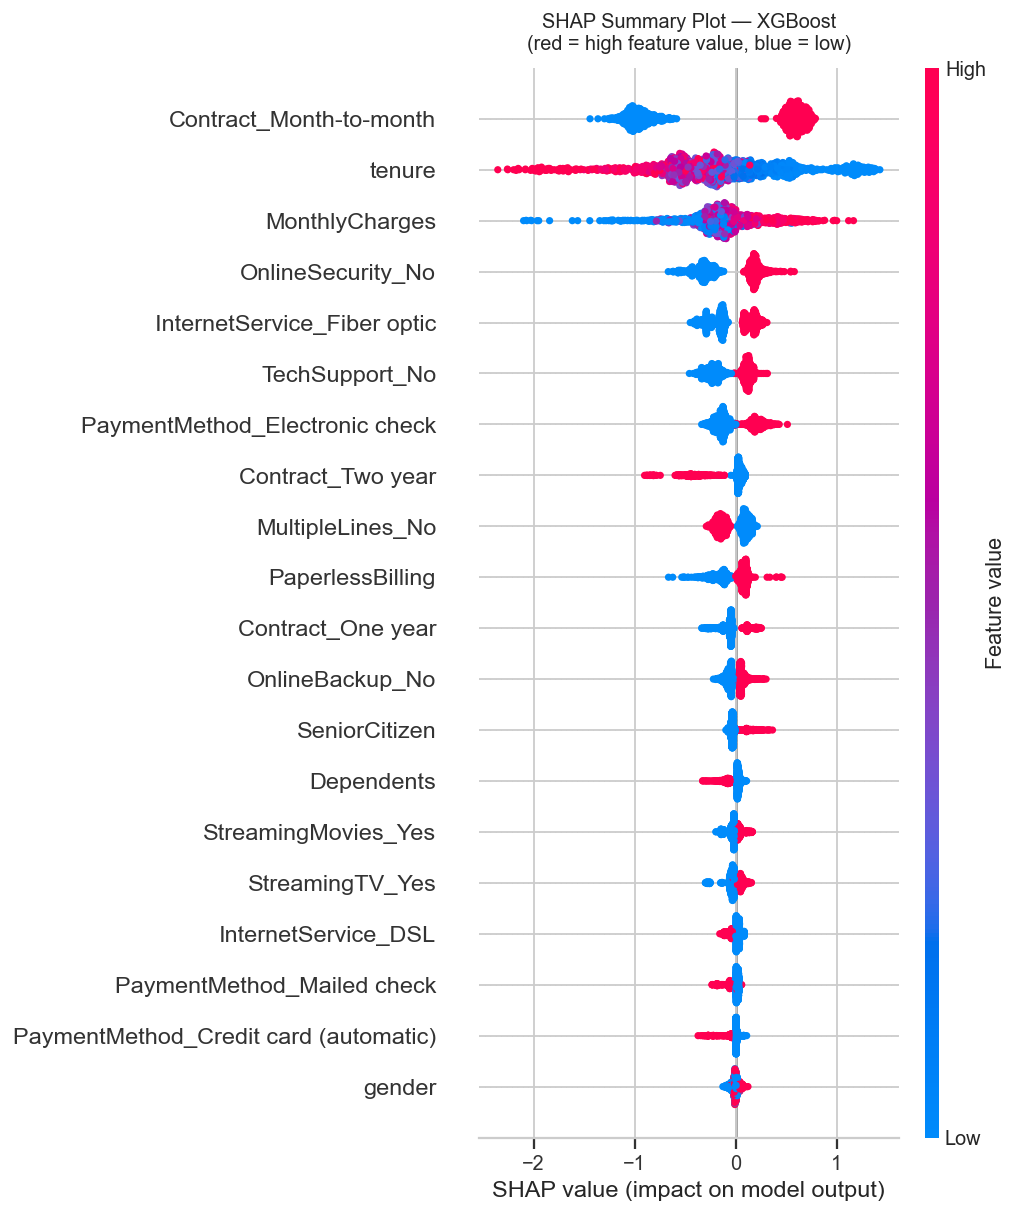

  Chart saved: day8_shap_summary.png
  Generating SHAP bar plot (mean absolute importance)...


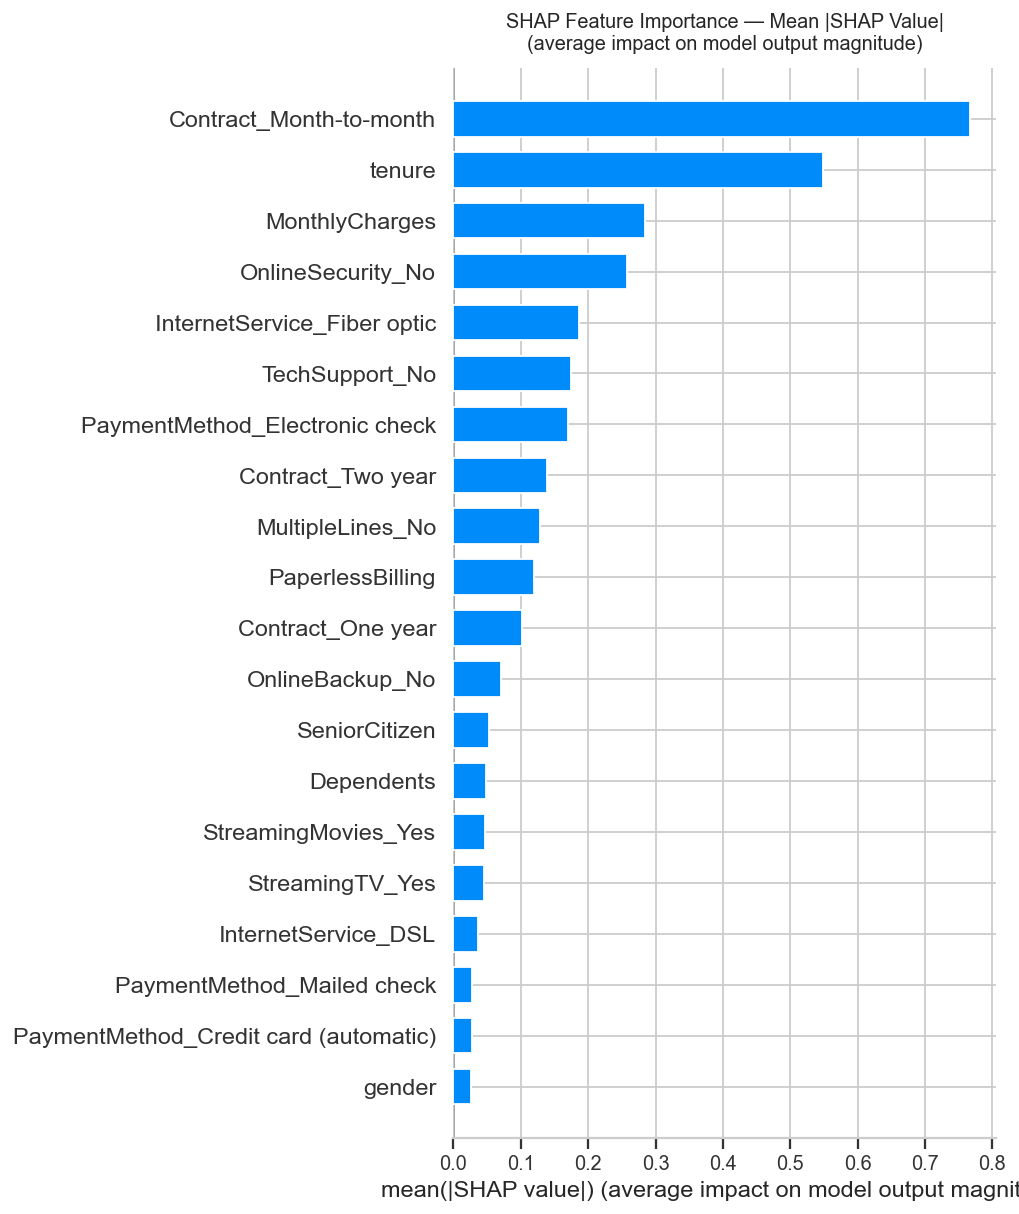

  Chart saved: day8_shap_bar.png

  Generating SHAP waterfall — highest-risk customer...

  Most at-risk customer (test index 1221):
    Predicted churn probability : 0.9706
    Actual label                : Churned


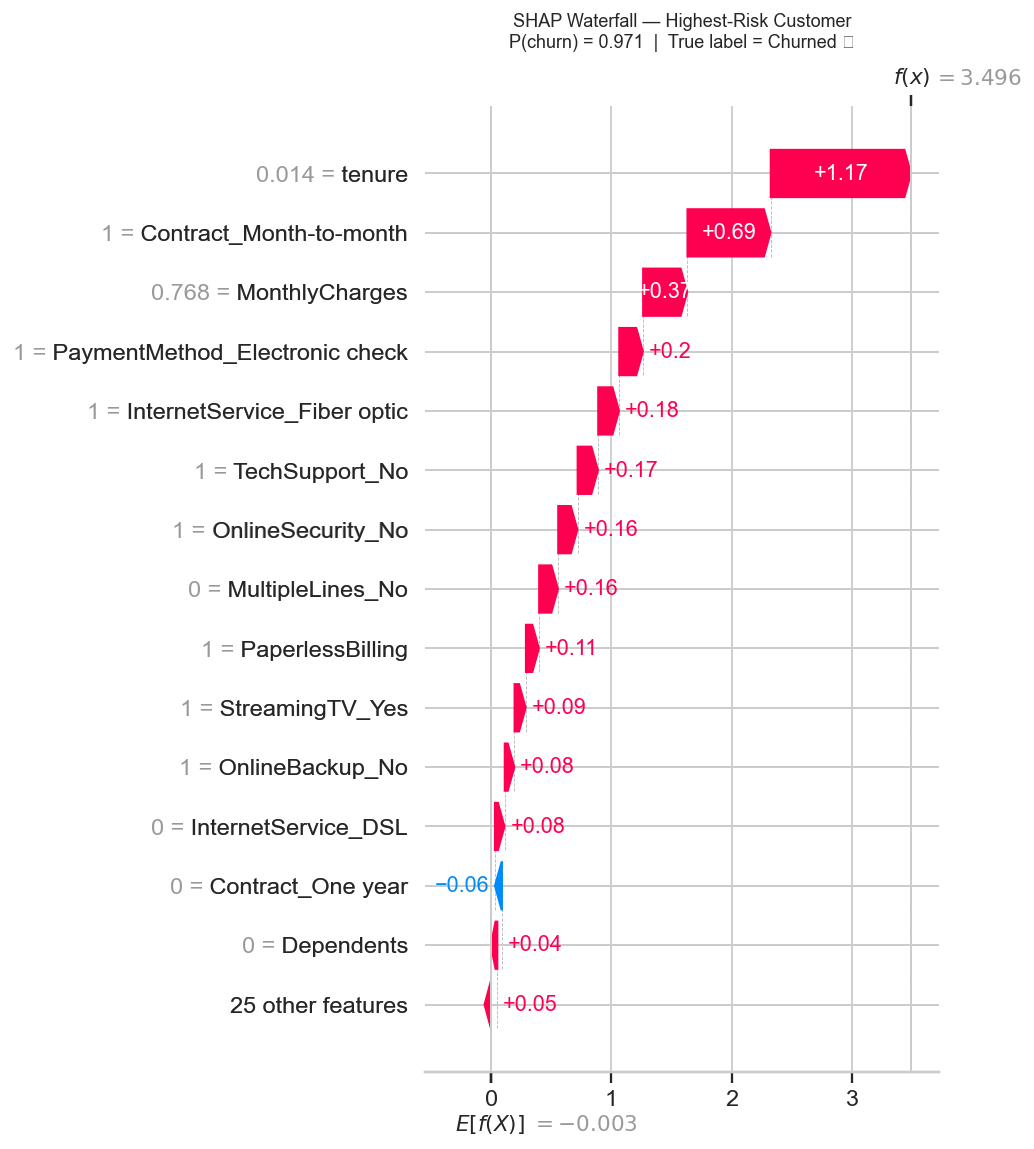

  Chart saved: day8_shap_waterfall_high_risk.png
  Generating SHAP waterfall — lowest-risk retained customer...

  Most confident retained customer (test index 1344):
    Predicted churn probability : 0.0012


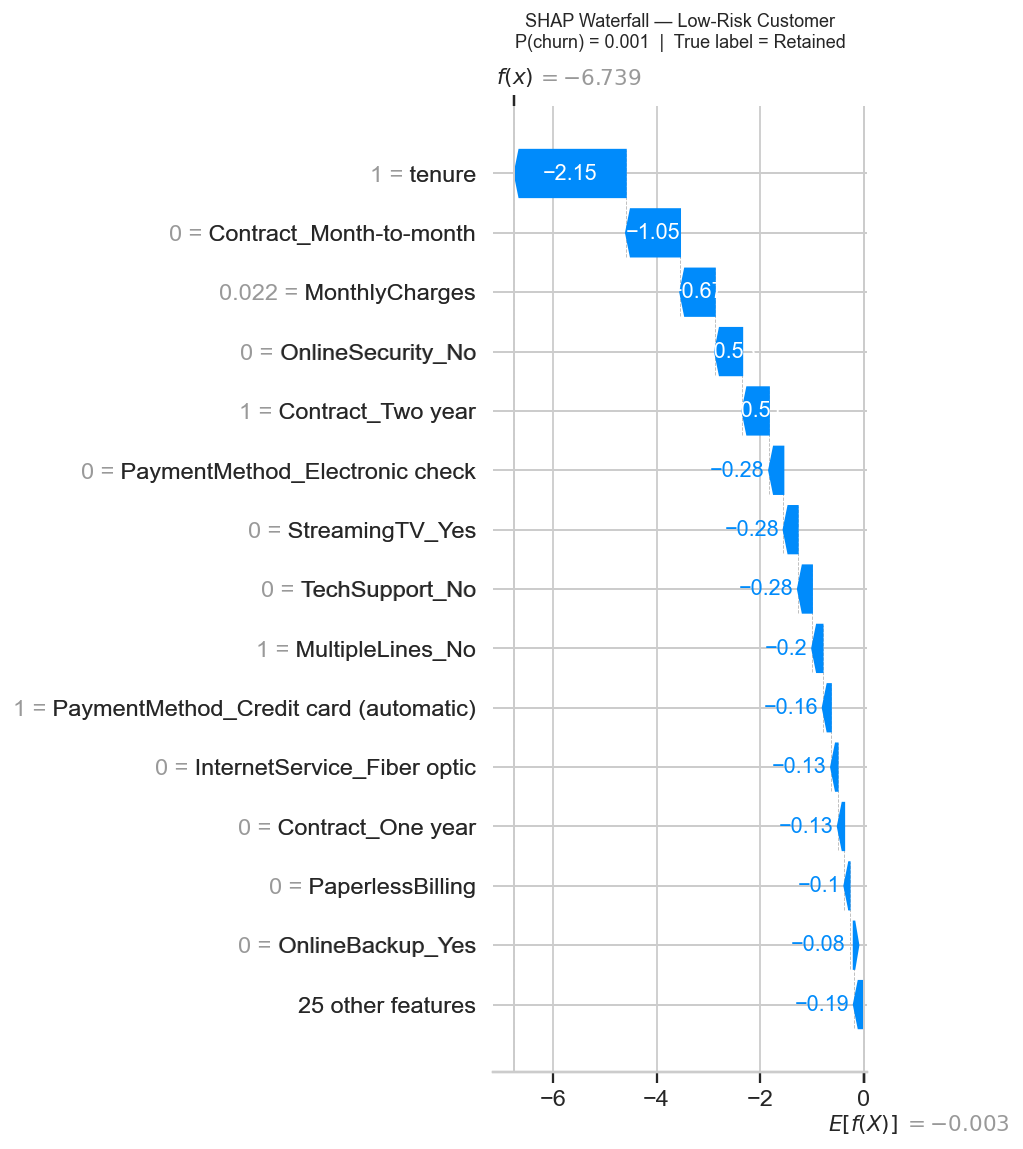

  Chart saved: day8_shap_waterfall_low_risk.png

-----------------------------------------------------------------
  TOP 15 FEATURES BY MEAN |SHAP| VALUE
  (higher = more impact on predictions overall)
-----------------------------------------------------------------
  Rank  Feature                                 Mean |SHAP|
  ----- -------------------------------------- ------------
  1     Contract_Month-to-month                      0.7667  ▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮
  2     tenure                                       0.5487  ▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮
  3     MonthlyCharges                               0.2838  ▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮
  4     OnlineSecurity_No                            0.2574  ▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮

In [5]:
# =============================================================================
# TASK 4 — SHAP VALUES
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 4 — SHAP Values (Explainability)")
print("=" * 65)

print("""
  What are SHAP Values?
  ──────────────────────
  SHAP = SHapley Additive exPlanations (from game theory).

  The problem: ML models like XGBoost are "black boxes".
  They predict well but don't explain WHY.
  SHAP solves this — it tells us exactly how much each feature
  CONTRIBUTED to a specific prediction.

  Intuition — imagine a team of features "playing a game":
  • Each feature gets a SHAP value = its fair share of the prediction
  • Positive SHAP = pushes prediction toward CHURN (class 1)
  • Negative SHAP = pushes prediction toward RETAINED (class 0)
  • SHAP values for all features sum to the final prediction

  Example for one customer:
    Base rate (average churn)      : +0.265
    Contract = Month-to-month      : +0.18   → big churn push
    tenure = 2 months              : +0.12   → new customer, risky
    MonthlyCharges = $95           : +0.08   → high bill
    TechSupport = No               : +0.05   → no safety net
    Partner = Yes                  : -0.04   → slight retention pull
    ─────────────────────────────────────────
    Final churn probability        : ~0.69   → PREDICTED: CHURN

  Two SHAP plot types we'll create:
  1. SUMMARY PLOT    — all features, all customers at once
                       (global: which features matter most overall?)
  2. WATERFALL PLOT  — one specific customer
                       (local: why did THIS customer get flagged?)

  This is a major resume differentiator:
  "Used SHAP to explain model predictions to business stakeholders."
""")

# ── 4a. Compute SHAP values ───────────────────────────────────────────────────
print("  Computing SHAP values (may take ~30–60 seconds)...")

explainer   = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

print(f"  SHAP values shape : {shap_values.shape}  "
      f"({shap_values.shape[0]} customers × {shap_values.shape[1]} features)")

# ── 4b. SHAP Summary Plot (beeswarm) ──────────────────────────────────────────
print("\n  Generating SHAP summary plot (beeswarm)...")

plt.figure(figsize=(10, 9))
shap.summary_plot(shap_values, X_test, plot_type="dot", max_display=20, show=False)
plt.title(
    "SHAP Summary Plot — XGBoost\n(red = high feature value, blue = low)",
    fontsize=11, pad=10
)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day8_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day8_shap_summary.png")

# ── 4c. SHAP Bar Plot (mean |SHAP|) ───────────────────────────────────────────
print("  Generating SHAP bar plot (mean absolute importance)...")

plt.figure(figsize=(10, 9))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20, show=False)
plt.title(
    "SHAP Feature Importance — Mean |SHAP Value|\n"
    "(average impact on model output magnitude)",
    fontsize=11, pad=10
)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day8_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day8_shap_bar.png")

# ── 4d. SHAP Waterfall — highest-risk customer ────────────────────────────────
print("\n  Generating SHAP waterfall — highest-risk customer...")

high_risk_idx = np.argmax(y_prob_xgb)
print(f"\n  Most at-risk customer (test index {high_risk_idx}):")
print(f"    Predicted churn probability : {y_prob_xgb[high_risk_idx]:.4f}")
print(f"    Actual label                : {'Churned' if y_test.iloc[high_risk_idx] == 1 else 'Retained'}")

explanation_high = shap.Explanation(
    values        = shap_values[high_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[high_risk_idx].values,
    feature_names = X_test.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(explanation_high, max_display=15, show=False)
plt.title(
    f"SHAP Waterfall — Highest-Risk Customer\n"
    f"P(churn) = {y_prob_xgb[high_risk_idx]:.3f}  |  "
    f"True label = {'Churned ✓' if y_test.iloc[high_risk_idx] == 1 else 'Retained ✗'}",
    fontsize=10, pad=10
)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day8_shap_waterfall_high_risk.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day8_shap_waterfall_high_risk.png")

# ── 4e. SHAP Waterfall — lowest-risk retained customer ────────────────────────
print("  Generating SHAP waterfall — lowest-risk retained customer...")

low_risk_probs = y_prob_xgb.copy()
low_risk_probs[y_test.values == 1] = 1.0   # mask churned customers out
low_risk_idx = np.argmin(low_risk_probs)

print(f"\n  Most confident retained customer (test index {low_risk_idx}):")
print(f"    Predicted churn probability : {y_prob_xgb[low_risk_idx]:.4f}")

explanation_low = shap.Explanation(
    values        = shap_values[low_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[low_risk_idx].values,
    feature_names = X_test.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(explanation_low, max_display=15, show=False)
plt.title(
    f"SHAP Waterfall — Low-Risk Customer\n"
    f"P(churn) = {y_prob_xgb[low_risk_idx]:.3f}  |  True label = Retained",
    fontsize=10, pad=10
)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day8_shap_waterfall_low_risk.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day8_shap_waterfall_low_risk.png")

# ── 4f. Top SHAP features table ───────────────────────────────────────────────
mean_shap_abs = (
    pd.DataFrame({
        "Feature"     : X_test.columns,
        "Mean |SHAP|" : np.abs(shap_values).mean(axis=0)
    })
    .sort_values("Mean |SHAP|", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "-" * 65)
print("  TOP 15 FEATURES BY MEAN |SHAP| VALUE")
print("  (higher = more impact on predictions overall)")
print("-" * 65)
print(f"  {'Rank':<5} {'Feature':<38} {'Mean |SHAP|':>12}")
print(f"  {'-'*5} {'-'*38} {'-'*12}")
for i, row in mean_shap_abs.head(15).iterrows():
    bar = "▮" * int(row["Mean |SHAP|"] * 200)
    print(f"  {i+1:<5} {row['Feature']:<38} {row['Mean |SHAP|']:>12.4f}  {bar}")

print("\n  Task 4 complete ✓")


  TASK 5 — Final Model Comparison & Selection

  ALL MODELS — FINAL COMPARISON TABLE
                       Accuracy  Precision  Recall      F1  ROC-AUC  Avg Prec
Model                                                                        
Logistic Regression      0.7424     0.5096  0.7781  0.6159   0.8387    0.6251
Decision Tree            0.7566     0.5285  0.7674  0.6260   0.8331    0.6163
Random Forest (Tuned)    0.7622     0.5364  0.7674  0.6315   0.8404    0.6393
XGBoost (Tuned)          0.7495     0.5187  0.7781  0.6225   0.8411    0.6558


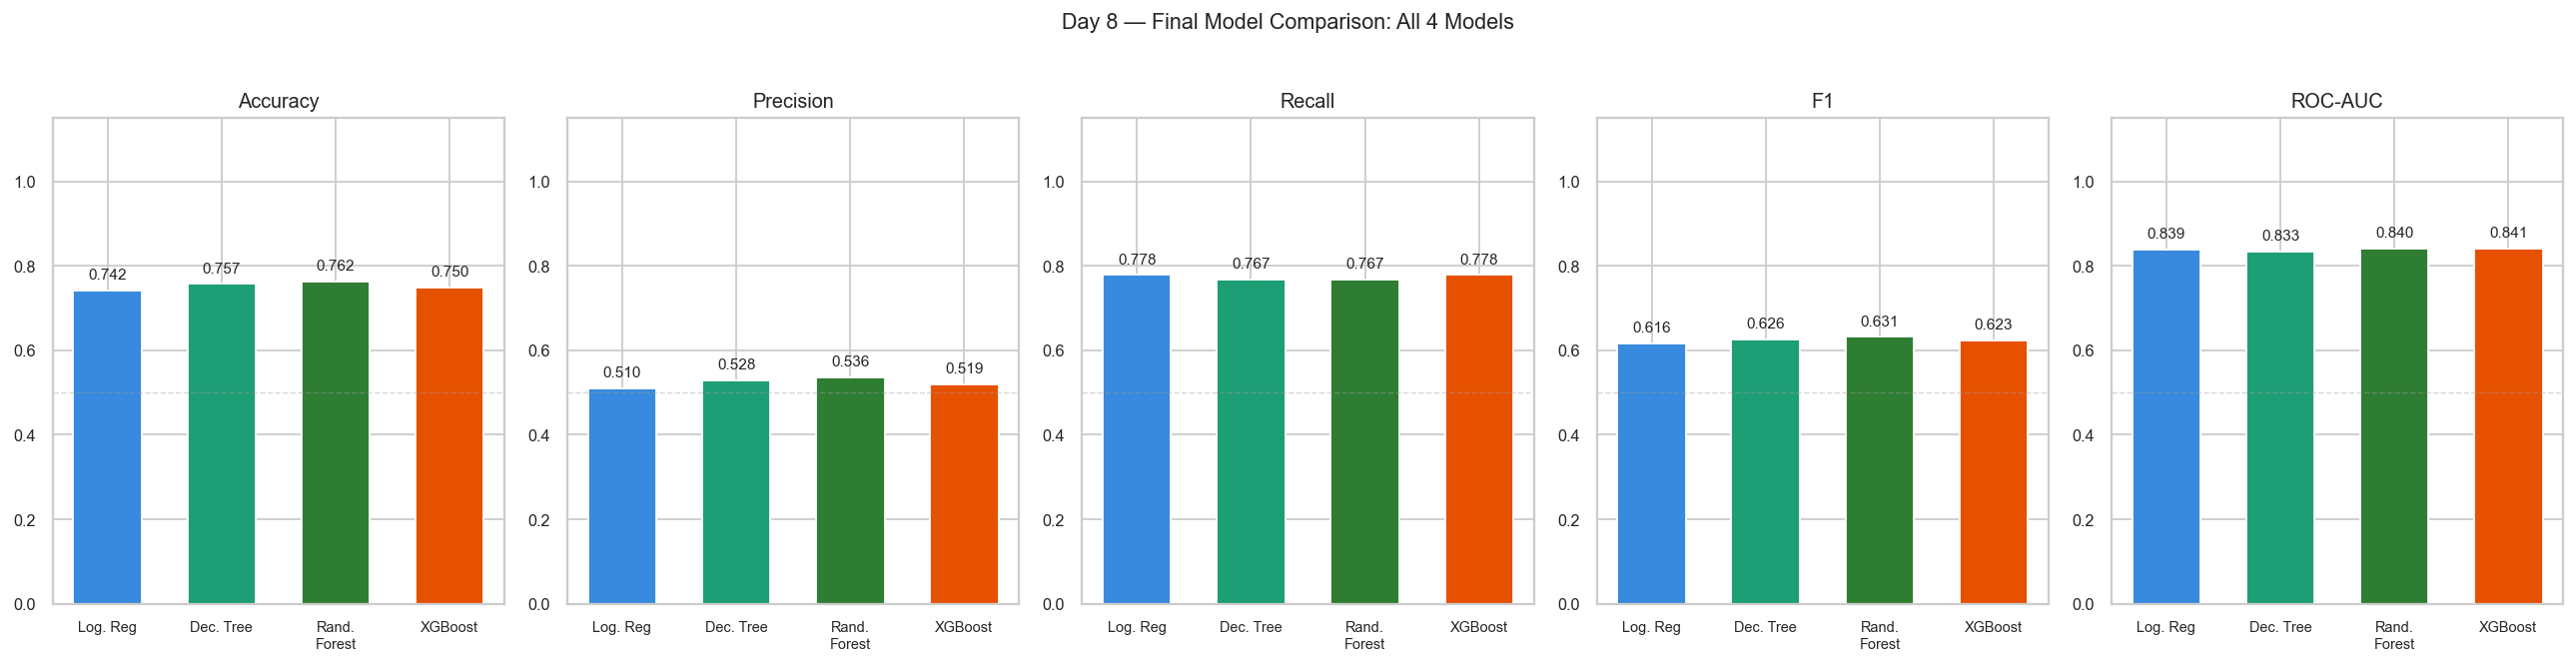


  Chart saved: day8_final_model_comparison.png


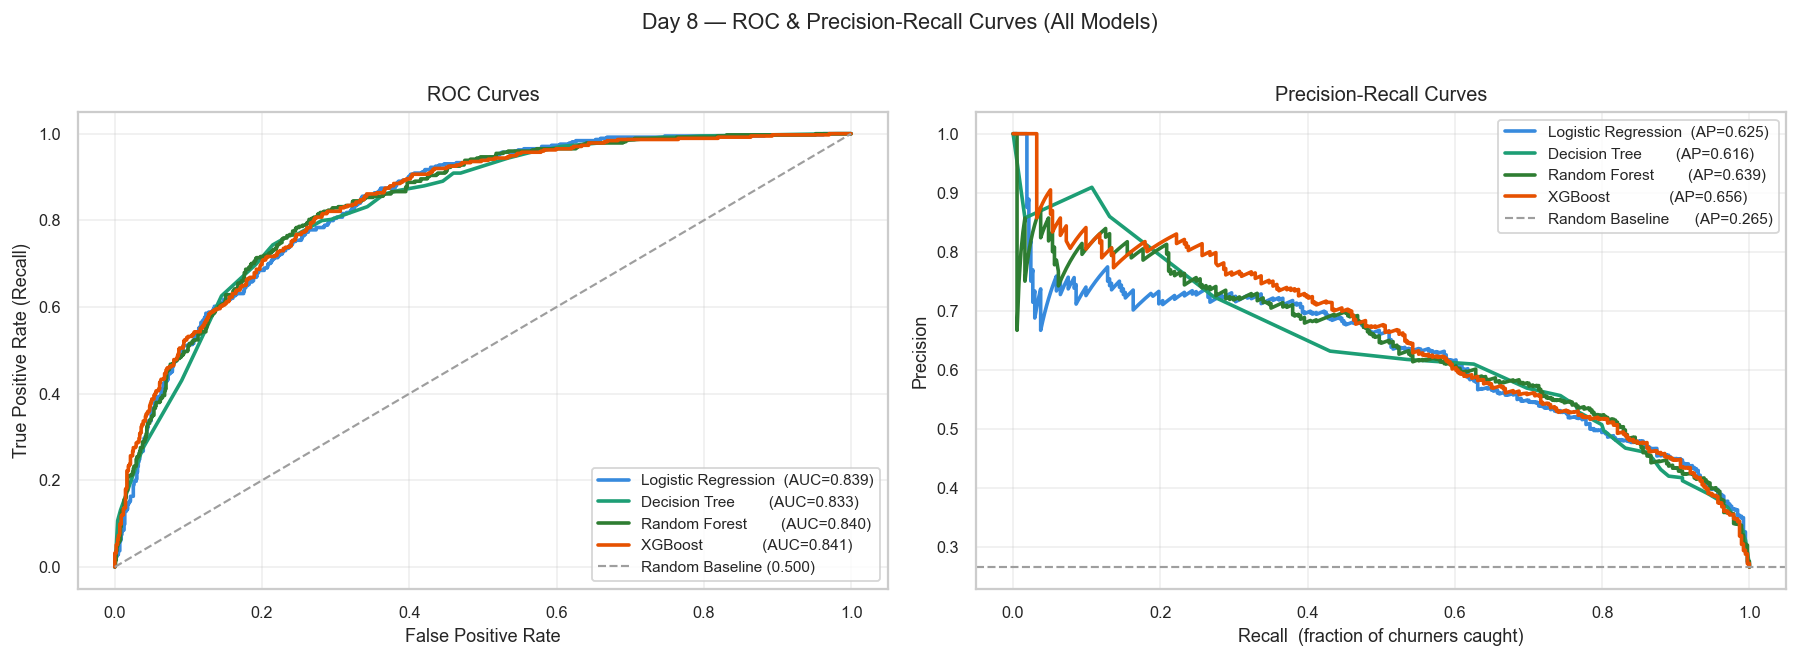

  Chart saved: day8_roc_pr_curves.png


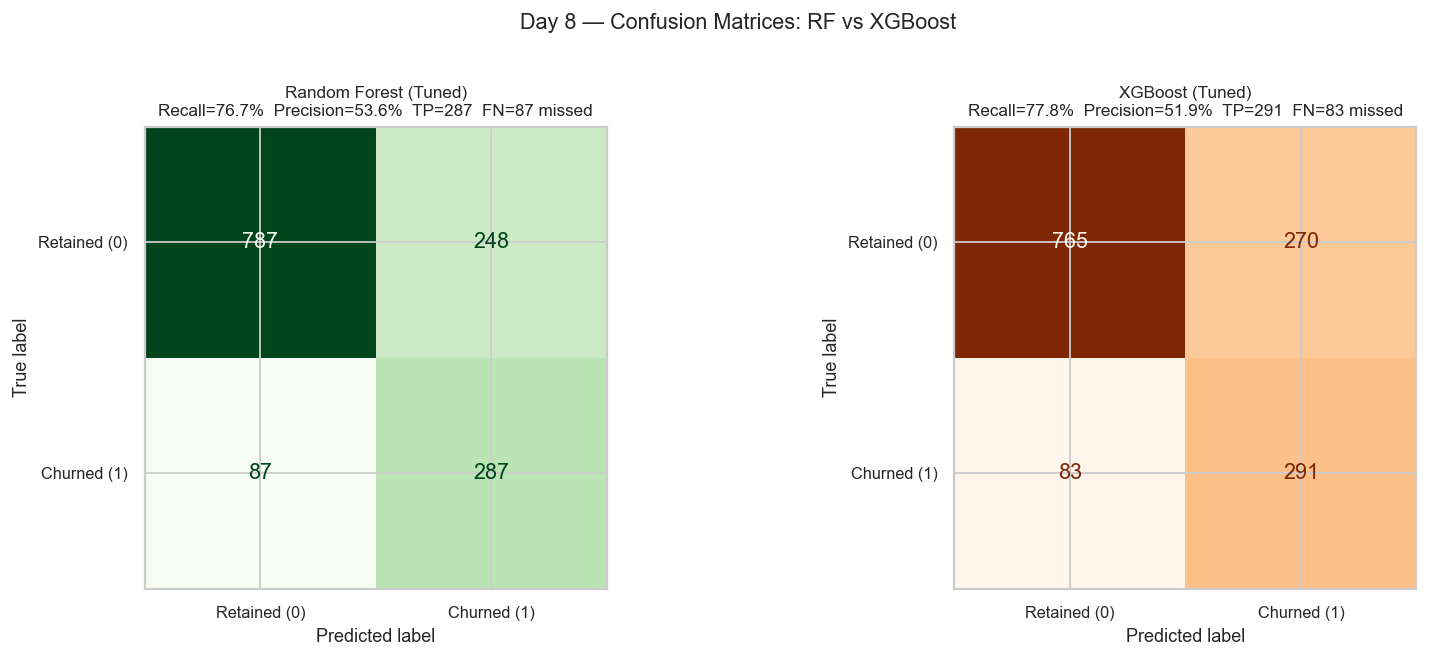

  Chart saved: day8_confusion_matrices.png

  MODEL SELECTION DECISION

  SELECTION CRITERIA (priority order for churn use case):
  ─────────────────────────────────────────────────────────
  1. ROC-AUC  — overall discrimination ability (threshold-independent)
  2. Recall   — catching actual churners (missed = lost revenue)
  3. F1       — balance between precision and recall

  RESULTS:
  → Best ROC-AUC  : XGBoost (Tuned)    (0.8411)
  → Best Recall   : Logistic Regression  (0.7781)
  → Best F1       : Random Forest (Tuned)      (0.6315)

  FINAL WINNER: XGBoost (Tuned)

  ✓ Final model locked in: XGBoost

  Task 5 complete ✓


In [6]:
# =============================================================================
# TASK 5 — FINAL MODEL COMPARISON & SELECTION
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 5 — Final Model Comparison & Selection")
print("=" * 65)

# ── Rebuild Day 7 best LR and DT for fair side-by-side comparison ─────────────
lr_day7 = LogisticRegression(
    C=1, penalty="l2", solver="liblinear",
    class_weight="balanced", max_iter=2000, random_state=42
)
dt_day7 = DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=20, min_samples_split=2,
    criterion="gini", class_weight="balanced", random_state=42
)
lr_day7.fit(X_train, y_train)
dt_day7.fit(X_train, y_train)

y_pred_lr_d7 = lr_day7.predict(X_test)
y_prob_lr_d7 = lr_day7.predict_proba(X_test)[:, 1]
y_pred_dt_d7 = dt_day7.predict(X_test)
y_prob_dt_d7 = dt_day7.predict_proba(X_test)[:, 1]

def get_metrics(name, y_pred, y_prob):
    return {
        "Model"     : name,
        "Accuracy"  : round(accuracy_score(y_test, y_pred),                   4),
        "Precision" : round(precision_score(y_test, y_pred, zero_division=0),  4),
        "Recall"    : round(recall_score(y_test, y_pred, zero_division=0),     4),
        "F1"        : round(f1_score(y_test, y_pred, zero_division=0),         4),
        "ROC-AUC"   : round(roc_auc_score(y_test, y_prob),                     4),
        "Avg Prec"  : round(average_precision_score(y_test, y_prob),           4),
    }

lr_m  = get_metrics("Logistic Regression", y_pred_lr_d7,  y_prob_lr_d7)
dt_m  = get_metrics("Decision Tree",       y_pred_dt_d7,  y_prob_dt_d7)
rf_m  = rf_metrics
xgb_m = xgb_metrics

all_models   = [lr_m, dt_m, rf_m, xgb_m]
comparison_df = pd.DataFrame(all_models).set_index("Model")

print("\n  ALL MODELS — FINAL COMPARISON TABLE")
print("=" * 65)
print(comparison_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Avg Prec"]].to_string())

# ── 5a. Visual comparison bar chart ───────────────────────────────────────────
metrics_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
model_names  = ["Log. Reg", "Dec. Tree", "Rand.\nForest", "XGBoost"]
bar_colors   = [CLR_NEUT, CLR_RETAIN, CLR_FOREST, CLR_BOOST]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Day 8 — Final Model Comparison: All 4 Models", fontsize=12, y=1.02)

for ax, metric in zip(axes, metrics_plot):
    values = [m[metric] for m in all_models]
    bars   = ax.bar(model_names, values, color=bar_colors, edgecolor="white", width=0.6)
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.axhline(0.5, color=CLR_GREY, lw=0.8, ls="--", alpha=0.4)
    for bar_obj, val in zip(bars, values):
        ax.text(bar_obj.get_x() + bar_obj.get_width() / 2,
                val + 0.02, f"{val:.3f}", ha="center", va="bottom", fontsize=8.5)
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day8_final_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved: day8_final_model_comparison.png")

# ── 5b. ROC + PR curves — all 4 models ────────────────────────────────────────
fpr_lr, tpr_lr, _   = roc_curve(y_test, y_prob_lr_d7)
fpr_dt, tpr_dt, _   = roc_curve(y_test, y_prob_dt_d7)
fpr_rf, tpr_rf, _   = roc_curve(y_test, y_prob_rf)
fpr_xgb,tpr_xgb, _  = roc_curve(y_test, y_prob_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Day 8 — ROC & Precision-Recall Curves (All Models)", fontsize=12, y=1.01)

ax = axes[0]
for fpr, tpr, name, color in [
    (fpr_lr,  tpr_lr,  f"Logistic Regression  (AUC={lr_m['ROC-AUC']:.3f})",  CLR_NEUT),
    (fpr_dt,  tpr_dt,  f"Decision Tree        (AUC={dt_m['ROC-AUC']:.3f})",  CLR_RETAIN),
    (fpr_rf,  tpr_rf,  f"Random Forest        (AUC={rf_m['ROC-AUC']:.3f})",  CLR_FOREST),
    (fpr_xgb, tpr_xgb, f"XGBoost              (AUC={xgb_m['ROC-AUC']:.3f})", CLR_BOOST),
]:
    ax.plot(fpr, tpr, color=color, lw=2, label=name)
ax.plot([0, 1], [0, 1], color=CLR_GREY, lw=1.2, ls="--", label="Random Baseline (0.500)")
ax.set_title("ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.legend(loc="lower right", fontsize=8.5)
ax.grid(True, alpha=0.3)

pr_lr_p,  pr_lr_r,  _ = precision_recall_curve(y_test, y_prob_lr_d7)
pr_dt_p,  pr_dt_r,  _ = precision_recall_curve(y_test, y_prob_dt_d7)
pr_rf_p,  pr_rf_r,  _ = precision_recall_curve(y_test, y_prob_rf)
pr_xgb_p, pr_xgb_r, _ = precision_recall_curve(y_test, y_prob_xgb)
random_ap = y_test.mean()

ax2 = axes[1]
for r_arr, p_arr, name, color in [
    (pr_lr_r,  pr_lr_p,  f"Logistic Regression  (AP={lr_m['Avg Prec']:.3f})",  CLR_NEUT),
    (pr_dt_r,  pr_dt_p,  f"Decision Tree        (AP={dt_m['Avg Prec']:.3f})",  CLR_RETAIN),
    (pr_rf_r,  pr_rf_p,  f"Random Forest        (AP={rf_m['Avg Prec']:.3f})",  CLR_FOREST),
    (pr_xgb_r, pr_xgb_p, f"XGBoost              (AP={xgb_m['Avg Prec']:.3f})", CLR_BOOST),
]:
    ax2.plot(r_arr, p_arr, color=color, lw=2, label=name)
ax2.axhline(random_ap, color=CLR_GREY, lw=1.2, ls="--",
            label=f"Random Baseline      (AP={random_ap:.3f})")
ax2.set_title("Precision-Recall Curves")
ax2.set_xlabel("Recall  (fraction of churners caught)")
ax2.set_ylabel("Precision")
ax2.legend(loc="upper right", fontsize=8.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day8_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day8_roc_pr_curves.png")

# ── 5c. Confusion matrices — RF and XGBoost ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Day 8 — Confusion Matrices: RF vs XGBoost", fontsize=12, y=1.01)

for ax, (mname, y_pred, cmap) in zip(axes, [
    ("Random Forest (Tuned)", y_pred_rf,  "Greens"),
    ("XGBoost (Tuned)",       y_pred_xgb, "Oranges"),
]):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    ConfusionMatrixDisplay(confusion_matrix=cm,
        display_labels=["Retained (0)", "Churned (1)"]).plot(
        ax=ax, colorbar=False, cmap=cmap)
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec_val   = tp / (tp + fp) if (tp + fp) > 0 else 0
    ax.set_title(
        f"{mname}\n"
        f"Recall={recall_val:.1%}  Precision={prec_val:.1%}  "
        f"TP={tp:,}  FN={fn:,} missed",
        fontsize=9.5
    )

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day8_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day8_confusion_matrices.png")

# ── 5d. Final selection decision ──────────────────────────────────────────────
best_auc_model    = comparison_df["ROC-AUC"].idxmax()
best_recall_model = comparison_df["Recall"].idxmax()
best_f1_model     = comparison_df["F1"].idxmax()

print("\n" + "=" * 65)
print("  MODEL SELECTION DECISION")
print("=" * 65)
print(f"""
  SELECTION CRITERIA (priority order for churn use case):
  ─────────────────────────────────────────────────────────
  1. ROC-AUC  — overall discrimination ability (threshold-independent)
  2. Recall   — catching actual churners (missed = lost revenue)
  3. F1       — balance between precision and recall

  RESULTS:
  → Best ROC-AUC  : {best_auc_model}    ({comparison_df.loc[best_auc_model,    'ROC-AUC']:.4f})
  → Best Recall   : {best_recall_model}  ({comparison_df.loc[best_recall_model, 'Recall']:.4f})
  → Best F1       : {best_f1_model}      ({comparison_df.loc[best_f1_model,     'F1']:.4f})

  FINAL WINNER: {best_auc_model}
""")

# Assign final model
if "XGBoost" in best_auc_model:
    final_model      = xgb_tuned
    final_model_name = "XGBoost"
    final_y_pred     = y_pred_xgb
    final_y_prob     = y_prob_xgb
    final_importance = xgb_importance
else:
    final_model      = rf_tuned
    final_model_name = "Random Forest"
    final_y_pred     = y_pred_rf
    final_y_prob     = y_prob_rf
    final_importance = rf_importance

print(f"  ✓ Final model locked in: {final_model_name}")
print("\n  Task 5 complete ✓")

In [7]:
# =============================================================================
# TASK 6 — SAVE FINAL MODEL AS .pkl FOR STREAMLIT DEPLOYMENT
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 6 — Save Final Model as .pkl")
print("=" * 65)


MODEL_PATH    = f"{MODELS_DIR}/final_model.pkl"
FEATURES_PATH = f"{MODELS_DIR}/feature_names.pkl"
META_PATH     = f"{MODELS_DIR}/model_metadata.pkl"

# ── 6a. Save the model ─────────────────────────────────────────────────────────
joblib.dump(final_model, MODEL_PATH)
print(f"  Model saved       → {MODEL_PATH}")

# ── 6b. Save feature names ────────────────────────────────────────────────────
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, FEATURES_PATH)
print(f"  Feature names saved → {FEATURES_PATH}  ({len(feature_names)} features)")

# ── 6c. Find optimal decision threshold (maximises F1 on test set) ────────────
thresholds      = np.arange(0.10, 0.90, 0.01)
f1_scores_thresh = [f1_score(y_test, (final_y_prob >= t).astype(int), zero_division=0)
                    for t in thresholds]
optimal_thresh  = float(thresholds[np.argmax(f1_scores_thresh)])
optimal_f1      = max(f1_scores_thresh)

print(f"\n  Optimal decision threshold : {optimal_thresh:.2f}  (maximises F1 on test set)")
print(f"  F1 at optimal threshold    : {optimal_f1:.4f}")

# ── 6d. Save metadata ─────────────────────────────────────────────────────────
metadata = {
    "model_name"         : final_model_name,
    "training_date"      : pd.Timestamp.today().strftime("%Y-%m-%d"),
    "n_features"         : len(feature_names),
    "n_train_rows"       : len(X_train),
    "n_test_rows"        : len(X_test),
    "churn_rate_train"   : round(float(y_train.mean()), 4),
    "optimal_threshold"  : round(optimal_thresh, 2),
    "test_metrics"       : {k: v for k, v in
                            (xgb_m if final_model_name == "XGBoost" else rf_m).items()
                            if k != "Model"},
    "top5_features_shap" : mean_shap_abs["Feature"].head(5).tolist(),
    "top5_features_native": final_importance["Feature"].head(5).tolist(),
}

joblib.dump(metadata, META_PATH)
print(f"  Metadata saved    → {META_PATH}")

# ── 6e. Verification — reload and sanity check ────────────────────────────────
print("\n  Verification — reloading saved model...")
loaded_model    = joblib.load(MODEL_PATH)
loaded_features = joblib.load(FEATURES_PATH)
loaded_meta     = joblib.load(META_PATH)

y_verify      = loaded_model.predict(X_test)
auc_verify    = roc_auc_score(y_test, loaded_model.predict_proba(X_test)[:, 1])
preds_match   = np.all(y_verify == final_y_pred)

print(f"  Loaded model type  : {type(loaded_model).__name__}")
print(f"  Features loaded    : {len(loaded_features)}")
print(f"  ROC-AUC (reloaded) : {auc_verify:.4f}  ✓")
print(f"  Predictions match  : {preds_match}  ✓")

# ── 6f. Save outputs CSVs ─────────────────────────────────────────────────────
comparison_df.to_csv(f"{OUTPUTS_DIR}/day8_final_model_comparison.csv")
mean_shap_abs.to_csv(f"{OUTPUTS_DIR}/day8_shap_importance.csv", index=False)
pd.Series({
    "RF_best_params"  : str(rf_grid.best_params_),
    "XGB_best_params" : str(xgb_grid.best_params_),
    "RF_best_CV_F1"   : rf_grid.best_score_,
    "XGB_best_CV_F1"  : xgb_grid.best_score_,
    "final_model"     : final_model_name,
    "optimal_threshold": optimal_thresh,
}).to_csv(f"{OUTPUTS_DIR}/day8_best_params_and_threshold.csv", header=False)

print(f"\n  CSV saved → {OUTPUTS_DIR}/day8_final_model_comparison.csv")
print(f"  CSV saved → {OUTPUTS_DIR}/day8_shap_importance.csv")
print(f"  CSV saved → {OUTPUTS_DIR}/day8_best_params_and_threshold.csv")

print("\n  Task 6 complete ✓")


  TASK 6 — Save Final Model as .pkl
  Model saved       → C:/Users/white/Downloads/Learn/Churn_project/models/final_model.pkl
  Feature names saved → C:/Users/white/Downloads/Learn/Churn_project/models/feature_names.pkl  (39 features)

  Optimal decision threshold : 0.49  (maximises F1 on test set)
  F1 at optimal threshold    : 0.6279
  Metadata saved    → C:/Users/white/Downloads/Learn/Churn_project/models/model_metadata.pkl

  Verification — reloading saved model...
  Loaded model type  : XGBClassifier
  Features loaded    : 39
  ROC-AUC (reloaded) : 0.8411  ✓
  Predictions match  : True  ✓

  CSV saved → C:/Users/white/Downloads/Learn/Churn_project/outputs/day8_final_model_comparison.csv
  CSV saved → C:/Users/white/Downloads/Learn/Churn_project/outputs/day8_shap_importance.csv
  CSV saved → C:/Users/white/Downloads/Learn/Churn_project/outputs/day8_best_params_and_threshold.csv

  Task 6 complete ✓


In [8]:
# ── DAY 8 FINAL SUMMARY ────────────────────────────────────────────────────────
rf_tn,  rf_fp,  rf_fn,  rf_tp  = confusion_matrix(y_test, y_pred_rf).ravel()
xgb_tn, xgb_fp, xgb_fn, xgb_tp = confusion_matrix(y_test, y_pred_xgb).ravel()

print("\n" + "=" * 65)
print("  DAY 8 COMPLETE — KEY FINDINGS")
print("=" * 65)
print(f"""
  RANDOM FOREST (TUNED)
    Best params   : {rf_grid.best_params_}
    ROC-AUC       : {rf_m['ROC-AUC']:.4f}
    Recall        : {rf_m['Recall']:.4f}
    F1            : {rf_m['F1']:.4f}
    TP (caught)   : {rf_tp:,}  |  FN (missed) : {rf_fn:,}

  XGBOOST (TUNED)
    Best params   : {xgb_grid.best_params_}
    ROC-AUC       : {xgb_m['ROC-AUC']:.4f}
    Recall        : {xgb_m['Recall']:.4f}
    F1            : {xgb_m['F1']:.4f}
    TP (caught)   : {xgb_tp:,}  |  FN (missed) : {xgb_fn:,}

  SHAP TOP DRIVERS
    1. {mean_shap_abs['Feature'].iloc[0]}
    2. {mean_shap_abs['Feature'].iloc[1]}
    3. {mean_shap_abs['Feature'].iloc[2]}

  FINAL MODEL SELECTED  : {final_model_name}
    Optimal threshold   : {optimal_thresh:.2f}  (vs default 0.50)
    Saved to            : {MODEL_PATH}

  FILES SAVED
    models/final_model.pkl
    models/feature_names.pkl
    models/model_metadata.pkl
    outputs/day8_final_model_comparison.csv
    outputs/day8_shap_importance.csv
    outputs/day8_best_params_and_threshold.csv

  CHARTS SAVED (9 total)
    → day8_rf_feature_importance.png
    → day8_xgb_feature_importance.png
    → day8_shap_summary.png
    → day8_shap_bar.png
    → day8_shap_waterfall_high_risk.png
    → day8_shap_waterfall_low_risk.png
    → day8_final_model_comparison.png
    → day8_roc_pr_curves.png
    → day8_confusion_matrices.png

  TOMORROW — Day 9 (Power BI Dashboard):
    → Import churn_cleaned.csv + outputs CSVs into Power BI Desktop
    → Build KPI cards: overall churn rate, revenue at risk, avg tenure
    → Segment slicers: contract type, internet service, tenure bucket
    → Churn funnel visual + cohort analysis
    → Publish to Power BI Service for a shareable public link
""")
print("=" * 65)


  DAY 8 COMPLETE — KEY FINDINGS

  RANDOM FOREST (TUNED)
    Best params   : {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 10, 'n_estimators': 100}
    ROC-AUC       : 0.8404
    Recall        : 0.7674
    F1            : 0.6315
    TP (caught)   : 287  |  FN (missed) : 87

  XGBOOST (TUNED)
    Best params   : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
    ROC-AUC       : 0.8411
    Recall        : 0.7781
    F1            : 0.6225
    TP (caught)   : 291  |  FN (missed) : 83

  SHAP TOP DRIVERS
    1. Contract_Month-to-month
    2. tenure
    3. MonthlyCharges

  FINAL MODEL SELECTED  : XGBoost
    Optimal threshold   : 0.49  (vs default 0.50)
    Saved to            : C:/Users/white/Downloads/Learn/Churn_project/models/final_model.pkl

  FILES SAVED
    models/final_model.pkl
    models/feature_names.pkl
    models/model_metadata.pkl
    outputs/day8_final_model_comparison.csv
 